In [ ]:

# CELL 1 — Mount Drive & Load Data

from google.colab import drive
drive.mount('/content/drive')

import numpy as np

SAVE_PATH = '/content/drive/MyDrive/FaceAttendance/data'

X_train = np.load(f'{SAVE_PATH}/X_attn_train.npy')
X_test  = np.load(f'{SAVE_PATH}/X_attn_test.npy')
y_train = np.load(f'{SAVE_PATH}/y_attn_train.npy')
y_test  = np.load(f'{SAVE_PATH}/y_attn_test.npy')

print(f'Attention data loaded!')
print(f'   Train: {X_train.shape} | Test: {X_test.shape}')
print(f'   Attentive: {sum(y_train==1)} | Distracted: {sum(y_train==0)}')

Mounted at /content/drive
Attention data loaded!
   Train: (2320, 64, 64, 3) | Test: (580, 64, 64, 3)
   Attentive: 1179 | Distracted: 1141


In [ ]:

# CELL 2 — Build Attention CNN Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')  # binary: attentive or distracted
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()
print('Attention model built!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,305 (4.86 MB)

 Trainable params: 1,273,857 (4.86 MB)

 Non-trainable params: 448 (1.75 KB)

Attention model built!


In [ ]:

# CELL 3 — Train Model

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

os.makedirs('/content/drive/MyDrive/FaceAttendance/models', exist_ok=True)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5',
                    save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)

print('Training complete!')

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6748 - loss: 1.5510
Epoch 1: val_loss improved from None to 1.05492, saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5



Epoch 1: finished saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.7341 - loss: 0.8162 - val_accuracy: 0.5172 - val_loss: 1.0549
Epoch 2/20
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8341 - loss: 0.3493
Epoch 2: val_loss did not improve from 1.05492
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8198 - loss: 0.3557 - val_accuracy: 0.5638 - val_loss: 1.1585
Epoch 3/20
69/73 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8269 - loss: 0.3537
Epoch 3: val_loss did not improve from 1.05492
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8254 - loss: 0.3516 - val_accuracy: 0.5500 - val_loss: 3.1344
Epoch 4/20
65/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8414 - loss: 0.3314
Epoch 4: val_loss improved from 1.05492 to 0.65347, saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5



Epoch 4: finished saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8397 - loss: 0.3210 - val_accuracy: 0.7000 - val_loss: 0.6535
Epoch 5/20
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8762 - loss: 0.2716
Epoch 5: val_loss improved from 0.65347 to 0.47947, saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5



Epoch 5: finished saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8703 - loss: 0.2807 - val_accuracy: 0.7603 - val_loss: 0.4795
Epoch 6/20
72/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9026 - loss: 0.2168
Epoch 6: val_loss improved from 0.47947 to 0.38750, saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5



Epoch 6: finished saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9017 - loss: 0.2191 - val_accuracy: 0.8086 - val_loss: 0.3875
Epoch 7/20
65/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9329 - loss: 0.1730
Epoch 7: val_loss improved from 0.38750 to 0.24423, saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5


...


Epoch 8: finished saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9431 - loss: 0.1482 - val_accuracy: 0.9397 - val_loss: 0.2164
Epoch 9/20
70/73 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9686 - loss: 0.0806
Epoch 9: val_loss improved from 0.21638 to 0.20596, saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5



Epoch 9: finished saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9685 - loss: 0.0836 - val_accuracy: 0.9155 - val_loss: 0.2060
Epoch 10/20
70/73 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9788 - loss: 0.0454
Epoch 10: val_loss improved from 0.20596 to 0.20423, saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5



Epoch 10: finished saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9802 - loss: 0.0535 - val_accuracy: 0.9155 - val_loss: 0.2042
Epoch 11/20
70/73 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9867 - loss: 0.0452
Epoch 11: val_loss improved from 0.20423 to 0.09341, saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5



Epoch 11: finished saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9836 - loss: 0.0474 - val_accuracy: 0.9655 - val_loss: 0.0934
Epoch 12/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9877 - loss: 0.0396
Epoch 12: val_loss did not improve from 0.09341
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9841 - loss: 0.0470 - val_accuracy: 0.9000 - val_loss: 0.2251
Epoch 13/20
65/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9916 - loss: 0.0368
Epoch 13: val_loss did not improve from 0.09341
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9905 - loss: 0.0340 - val_accuracy: 0.9621 - val_loss: 0.1143
Epoch 14/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9983 - loss: 0.0088
Epoch 14: val_loss improved from 0.09341 to 0.04796, saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5



Epoch 14: finished saving model to /content/drive/MyDrive/FaceAttendance/models/attention_classifier.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9978 - loss: 0.0096 - val_accuracy: 0.9862 - val_loss: 0.0480
Epoch 15/20
65/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0040
Epoch 15: val_loss did not improve from 0.04796
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9974 - loss: 0.0088 - val_accuracy: 0.9621 - val_loss: 0.1286
Epoch 16/20
70/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9927 - loss: 0.0262
Epoch 16: val_loss did not improve from 0.04796
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9931 - loss: 0.0252 - val_accuracy: 0.9655 - val_loss: 0.0905
Epoch 17/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9904 - loss: 0.0368
Epoch 17: val_loss did not improve from 0.04796
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9845 - loss: 0.0589 - val_accuracy: 0.9052 - val_loss: 0.2923
Epoch 18/20
65/73 ━━━━━━━━━━━━━━━━━

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9862 - loss: 0.0480
Test Accuracy: 98.62%


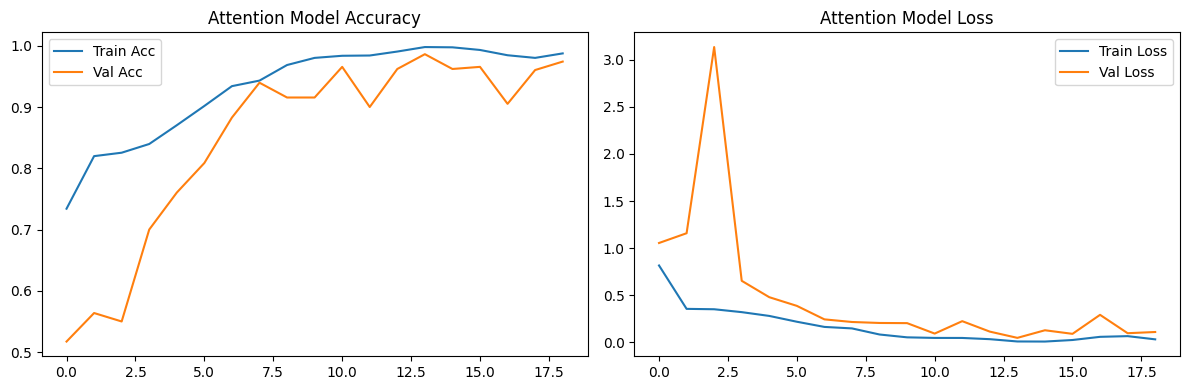

Plot saved to Drive!


In [ ]:

# CELL 4 — Evaluate & Plot

import matplotlib.pyplot as plt

loss, acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {acc*100:.2f}%')

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Attention Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Attention Model Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FaceAttendance/attention_plot.png')
plt.show()
print('Plot saved to Drive!')